<a href="https://colab.research.google.com/github/haritraman/job_fraud_detection_nuerosymbolic/blob/main/nuero_late_emscad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📥 Downloading and processing EMSCAD...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🚀 Starting Two-Tower Late Fusion Training...

✅ Epoch 1/5 | Train Acc: 79.24% | Val Acc: 88.60%
✅ Epoch 2/5 | Train Acc: 91.57% | Val Acc: 90.87%
✅ Epoch 3/5 | Train Acc: 95.53% | Val Acc: 95.43%
✅ Epoch 4/5 | Train Acc: 97.50% | Val Acc: 96.82%
✅ Epoch 5/5 | Train Acc: 97.87% | Val Acc: 97.26%
🔥 Training Complete!

📊 Classification Report:

              precision    recall  f1-score   support

       Legit       0.99      0.98      0.99      3038
        Fake       0.65      0.77      0.71       137

    accuracy                           0.97      3175
   macro avg       0.82      0.88      0.85      3175
weighted avg       0.98      0.97      0.97      3175

📈 AUC-ROC Score: 0.9696



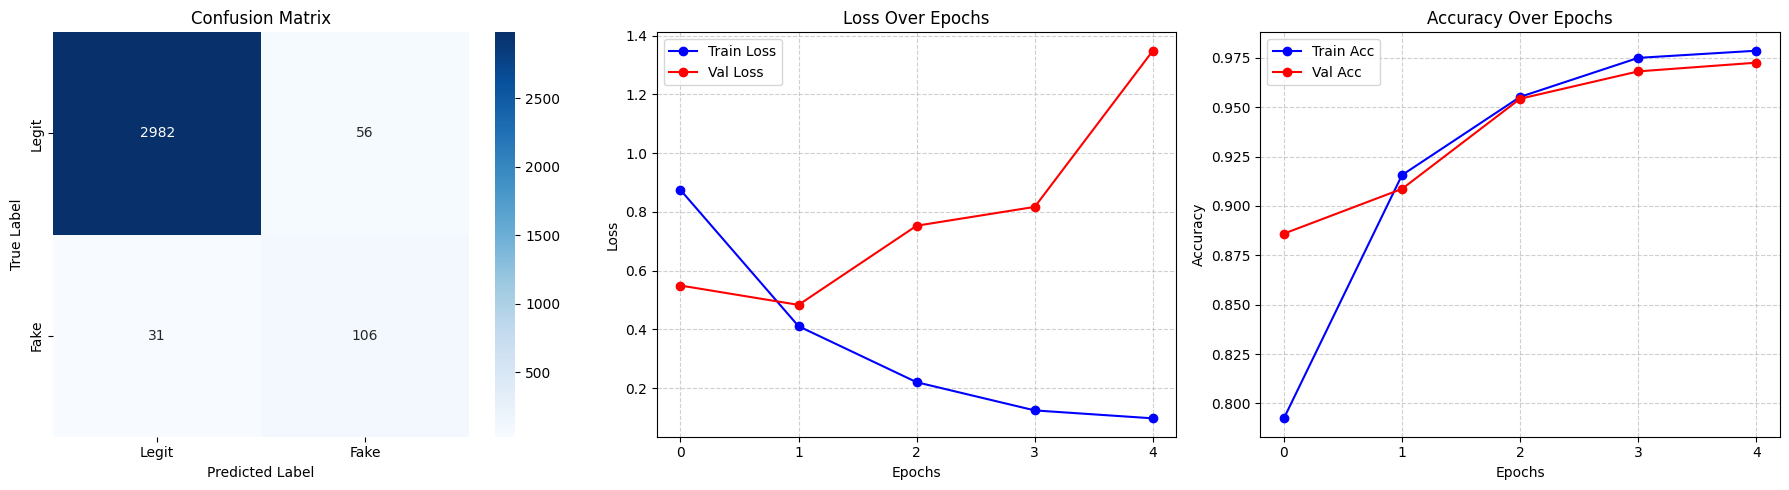


✅ New Late Fusion Model Saved as 'emscad_late_fusion_model.pth'. Download this file!


In [ ]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from transformers import DistilBertModel, DistilBertTokenizer
import gdown
import matplotlib.pyplot as plt
import seaborn as sns

# ================= 1. SYMBOLIC RULES ENGINE =================
def apply_symbolic_rules(row):
    desc = str(row.get('description', '')).lower()
    title = str(row.get('title', '')).lower()
    raw_title = str(row.get('title', ''))
    profile = str(row.get('company_profile', '')).lower()
    try:
        logo = int(row.get('has_company_logo', 0))
    except:
        logo = 0

    vec = [0] * 15
    if re.search(r'(registration fee|processing fee|security deposit|ssn|social security|bank account)', desc): vec[0] = 1
    if re.search(r'(whatsapp|telegram|@gmail|@yahoo|@hotmail|@outlook)', desc): vec[1] = 1
    if re.search(r'(urgent hiring|apply immediately|limited seats|hired on the spot|no interview|start immediately)', desc): vec[2] = 1
    if re.search(r'(no experience|entry level)', desc) and re.search(r'(\$5000|\$5,000|high salary|easy work|1000/week)', desc): vec[3] = 1
    if (raw_title.isupper() and len(raw_title) > 4) or re.search(r'(earn|weekly|quick money|immediate|hiring now)', title): vec[4] = 1
    if re.search(r'(data entry|virtual assistant|package handler|reshipping)', title): vec[5] = 1
    if len(profile) < 50: vec[6] = 1
    if re.search(r'(fast-growing|leading organization|multinational)', profile) and not re.search(r'(www\.|http|\.com|\.org|\.net)', profile): vec[7] = 1
    if logo == 0 and vec[6] == 1: vec[8] = 1
    if logo == 0 and vec[1] == 1: vec[9] = 1
    if re.search(r'(usdt|crypto wallet|bitcoin|ethereum|metamask|trust wallet)', desc): vec[10] = 1

    # R12: Sketchy URLs
    if re.search(r'(bit\.ly|tinyurl\.com|google forms|forms\.gle)', desc): vec[11] = 1

    # R13: Click Farms / Task Scams
    if re.search(r'(download our app|rate 5 stars|app testing|click tasks|daily tasks)', desc): vec[12] = 1

    # R14: Zero Skill Requirements
    if re.search(r'(must be 18|basic english|internet connection|smartphone required)', desc): vec[13] = 1

    # R15: Spammy Punctuation (Excessive Exclamation Marks)
    if desc.count('!') > 4: vec[14] = 1
    return vec

# ================= 2. DATA PREPARATION =================
print("📥 Downloading and processing EMSCAD...")
emscad_id = '15lcwS3slEEmOF6J_D25I3Ed5Oq6zmmdI'
gdown.download(f'https://drive.google.com/uc?id={emscad_id}', 'emscad.csv', quiet=True)
emscad = pd.read_csv('emscad.csv', encoding='latin-1')

emscad['label'] = emscad['fraudulent'].map({'f': 0, 't': 1})
emscad['text'] = emscad['title'].fillna('') + " " + emscad['description'].fillna('')
emscad['text'] = emscad['text'].apply(lambda x: re.sub(r'<[^>]+>', '', str(x)).strip())
emscad.drop_duplicates(subset=['text'], inplace=True)
emscad['rule_vector'] = emscad.apply(apply_symbolic_rules, axis=1)

texts = emscad['text'].tolist()
rule_vectors = emscad['rule_vector'].tolist()
labels = emscad['label'].tolist()

# ================= 3. DATASET & DATALOADER =================
class HybridJobDataset(Dataset):
    def __init__(self, texts, rule_vectors, labels):
        self.texts = texts
        self.rule_vectors = rule_vectors
        self.labels = labels
        self.tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), padding='max_length', truncation=True, max_length=256, return_tensors='pt')
        return {
            'ids': enc['input_ids'].flatten(),
            'mask': enc['attention_mask'].flatten(),
            'rules': torch.tensor(self.rule_vectors[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.float)
        }

train_texts, val_texts, train_rules, val_rules, train_labels, val_labels = train_test_split(
    texts, rule_vectors, labels, test_size=0.2, stratify=labels, random_state=42
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader = DataLoader(HybridJobDataset(train_texts, train_rules, train_labels), batch_size=16, shuffle=True)
val_loader = DataLoader(HybridJobDataset(val_texts, val_rules, val_labels), batch_size=16)

# ================= 4. THE LATE FUSION ARCHITECTURE =================
class LateFusionNeurosymbolic(nn.Module):
    def __init__(self, rule_dim=15):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.dropout = nn.Dropout(0.3)

        # Tower 1: Text Logic
        self.text_classifier = nn.Linear(768, 1)
        # Tower 2: Symbolic Logic
        self.rule_classifier = nn.Linear(rule_dim, 1)

    def forward(self, input_ids, attention_mask, rules):
        # 1. Text Analysis (BERT is now awake!)
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(outputs.last_hidden_state[:, 0, :])
        text_logits = self.text_classifier(cls)

        # 2. Rule Analysis
        rule_logits = self.rule_classifier(rules)

        # 3. EXPLICIT LATE FUSION (Logit Summation)
        final_logits = text_logits + rule_logits
        return final_logits

model = LateFusionNeurosymbolic(rule_dim=15).to(device)

# ================= 5. TRAINING SETUP =================
optimizer = torch.optim.AdamW([
    {'params': model.bert.parameters(), 'lr': 2e-5},
    {'params': model.text_classifier.parameters(), 'lr': 1e-3},
    {'params': model.rule_classifier.parameters(), 'lr': 1e-3}
], weight_decay=0.01)

pos_weight = torch.tensor([len(train_labels)/sum(train_labels)]).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ================= 6. TRAINING LOOP =================
EPOCHS = 5
print("\n🚀 Starting Two-Tower Late Fusion Training...\n")

# Dictionary to store metrics for the graphs
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train()
    train_loss, correct_train, total_train = 0, 0, 0

    for i, batch in enumerate(train_loader):
        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        rules = batch['rules'].to(device)
        labels_batch = batch['label'].unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(ids, mask, rules)
        loss = loss_fn(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct_train += (preds == labels_batch).sum().item()
        total_train += labels_batch.size(0)

    # Validation
    model.eval()
    val_loss, correct_val, total_val = 0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            ids = batch['ids'].to(device)
            mask = batch['mask'].to(device)
            rules = batch['rules'].to(device)
            labels_batch = batch['label'].unsqueeze(1).to(device)

            outputs = model(ids, mask, rules)
            val_loss += loss_fn(outputs, labels_batch).item()

            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct_val += (preds == labels_batch).sum().item()
            total_val += labels_batch.size(0)

    # Calculate averages for the epoch
    epoch_train_loss = train_loss / len(train_loader)
    epoch_val_loss = val_loss / len(val_loader)
    epoch_train_acc = correct_train / total_train
    epoch_val_acc = correct_val / total_val

    # Store in history
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    print(f"✅ Epoch {epoch+1}/{EPOCHS} | Train Acc: {epoch_train_acc*100:.2f}% | Val Acc: {epoch_val_acc*100:.2f}%")

print("🔥 Training Complete!")

# ================= 7. EVALUATION & VISUALIZATION =================
all_preds, all_labels, all_probs = [], [], []
model.eval()
with torch.no_grad():
    for batch in val_loader:
        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        rules = batch['rules'].to(device)
        labels_batch = batch['label'].to(device)

        logits = model(ids, mask, rules)
        probs = torch.sigmoid(logits).view(-1) # Flatten probabilities
        preds = (probs > 0.5).float()

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

print("\n📊 Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=['Legit','Fake']))

auc_score = roc_auc_score(all_labels, all_probs)
print(f"📈 AUC-ROC Score: {auc_score:.4f}\n")

# --- PLOTTING GRAPHS ---
plt.figure(figsize=(18, 5))

# Plot 1: Confusion Matrix
plt.subplot(1, 3, 1)
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fake'],
            yticklabels=['Legit', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# Plot 2: Train vs Validation Loss
plt.subplot(1, 3, 2)
plt.plot(history['train_loss'], label='Train Loss', marker='o', color='blue')
plt.plot(history['val_loss'], label='Val Loss', marker='o', color='red')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(EPOCHS))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Train vs Validation Accuracy
plt.subplot(1, 3, 3)
plt.plot(history['train_acc'], label='Train Acc', marker='o', color='blue')
plt.plot(history['val_acc'], label='Val Acc', marker='o', color='red')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(range(EPOCHS))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ================= 8. SAVING MODEL =================
torch.save(model.state_dict(), "emscad_late_fusion_model.pth")
print("\n✅ New Late Fusion Model Saved as 'emscad_late_fusion_model.pth'. Download this file!")

In [ ]:
from google.colab import files

# Replace 'model.h5' with your actual file name
files.download('emscad_late_fusion_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>